# Sample client usage of Quantization Service

#### sample to set up service server
see https://github.com/vuiseng9/nncf/blob/qaas-dec2021/qaas/host_qaas_image_classification.sh
    

In [1]:
import os, time, random, torch, sys, requests, json
import numpy as np, pandas as pd
from copy import deepcopy
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
host_url = 'http://csr-dgx1-03.jf.intel.com:5000/'

In [3]:
url_ready = host_url + 'ready_state'
url_graphviz = host_url + 'get_model_graph_viz'
url_optype = host_url + 'get_node2optype_map'
url_connectivity = host_url + 'get_connectivity_map'
url_quantizable = host_url + 'get_quantizable_attr'
url_graph_features = host_url + 'layer_graph_data'
url_eval_req = host_url + 'sample_eval_req'
url_evaluate = host_url + 'evaluate'
url_test = host_url + 'test'

#### Check if service is ready

In [4]:
requests.get(url=url_ready).json()

{'config': '/workspace/nncf/qaas/cfg/bert_squad_qaas.json',
 'method': 'ready_state',
 'msg': 'Environment bert-squad initialized',
 'rc': 0}

#### Graph visualization

Note: you can download through browser with this url http://csr-dgx1-03.jf.intel.com:15040/get_model_graph_viz


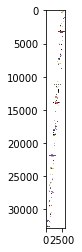

In [5]:
# download a copy of model graph with colorized grouped quantizer nodes
print('Note: you can download through browser with this url {}'.format(url_graphviz))

imgpth = 'model_graph.png'
r = requests.get(url_graphviz, allow_redirects=True)
with open(imgpth, 'wb') as fh:
    fh.write(r.content)

plt.imshow(plt.imread(imgpth))

### Graph node to operation type

In [6]:
node_type=requests.get(url=url_optype).json()
node_type

{'0 /nncf_model_input_0': 'nncf_model_input',
 '1 /nncf_model_input_1': 'nncf_model_input',
 '10 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/__add___0': '__add__',
 '100 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/__add___0': '__add__',
 '101 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/AsymmetricQuantizer/asymmetric_quantize_0': 'asymmetric_quantize',
 '102 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/LayerNorm[LayerNorm]/layer_norm_0': 'layer_norm',
 '103 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/LayerNorm[LayerNorm]/AsymmetricQuantizer/asymmetric_quantize_0': 'asymmetric_quantiz

### Connectivity of nodes

In [7]:
node_conn = requests.get(url=url_connectivity).json()
# key of the dictionary is source node
# value is a list of destination nodes

# nodetype can be looked up via previous mapping

for i, (src_node, dst_nodes) in enumerate(node_conn.items()):
    print("* ({}) {}".format(node_type[src_node], src_node))
    for dst_node in dst_nodes:
        print("\t-> ({}) {}".format(node_type[dst_node], dst_node))
    print("")
    if i>=5:
        break

* (nncf_model_input) 0 /nncf_model_input_0
	-> (embedding) 5 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/embedding_0

* (nncf_model_input) 1 /nncf_model_input_1
	-> (__getitem__) 3 BertForQuestionAnswering/BertModel[bert]/__getitem___0

* (__add__) 10 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/__add___0
	-> (asymmetric_quantize) 11 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/AsymmetricQuantizer/asymmetric_quantize_0

* (__add__) 100 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/__add___0
	-> (asymmetric_quantize) 101 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/AsymmetricQuantizer/asymmetric_quantize_0

* (asymmetric_quantize) 101 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/Modu

### Features of quantizable nodes

In [8]:
url_quantizable

'http://csr-dgx1-03.jf.intel.com:15040/get_quantizable_attr'

In [9]:
quantizable_attr = requests.get(url=url_quantizable).json()

In [10]:
quantizable_df = pd.DataFrame.from_dict(quantizable_attr)

In [11]:
quantizable_df.head()

,gid,is_wt_quantizer,n_axis,n_feature,node_name,target_optype
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/LayerNorm[LayerNorm]/layer_norm_0|OUTPUT,88,0.0,3,294912,18 BertForQuestionAnswering/BertModel[bert]/Be...,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/embedding_0|OUTPUT,1,0.0,3,294912,14 BertForQuestionAnswering/BertModel[bert]/Be...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/embedding_0|WEIGHT,1,1.0,2,393216,12 BertForQuestionAnswering/BertModel[bert]/Be...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[token_type_embeddings]/embedding_0|OUTPUT,0,0.0,3,294912,9 BertForQuestionAnswering/BertModel[bert]/Ber...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[token_type_embeddings]/embedding_0|WEIGHT,0,1.0,2,1536,7 BertForQuestionAnswering/BertModel[bert]/Ber...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


Nodes grouped as a cluster can be found in this table by ```gid```. ```node_name``` can be used to looked up optype and connectivity map.

In [12]:
node2gid = quantizable_df[['node_name', 'gid']].set_index('node_name').to_dict()

In [13]:
node2gid['gid']

{'18 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/LayerNorm[LayerNorm]/AsymmetricQuantizer/asymmetric_quantize_0': 88,
 '14 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/AsymmetricQuantizer/asymmetric_quantize_0': 1,
 '12 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0': 1,
 '9 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[token_type_embeddings]/AsymmetricQuantizer/asymmetric_quantize_0': 0,
 '7 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[token_type_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0': 0,
 '6 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/AsymmetricQuantizer/asymmetric_quantize_0': 0,
 '4 Be

#### Features per Node API

In [14]:
graph_features = requests.get(url=url_graph_features).json()

In [15]:
graph_feature_df = pd.DataFrame.from_dict(graph_features)

In [16]:
graph_features.keys()

dict_keys(['action_space', 'edges', 'node_features', 'rc'])

In [17]:
graph_features['action_space']

{'discrete': [2, 3, 4, 5, 6, 7, 8]}

#### Sample evaluation configuration

In [18]:
eval_cfg = requests.get(url=url_eval_req).json()
# key is quantization group id
# value is the bitwidth of a node
eval_cfg

{'bool_bnadap': True,
 'bw_cfg': {'0 /nncf_model_input_0': 0,
  '1 /nncf_model_input_1': 0,
  '10 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/__add___0': 0,
  '100 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/__add___0': 0,
  '101 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/AsymmetricQuantizer/asymmetric_quantize_0': 5,
  '102 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/LayerNorm[LayerNorm]/layer_norm_0': 0,
  '103 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/LayerNorm[LayerNorm]/AsymmetricQuantizer/asymmetric_quantize_0': 7,
  '104 BertForQuestionAnswering/BertModel[bert]/BertEncode

#### Evaluation with random bitwidth (reuse sample request above)

In [19]:
# print eval_cfg to see more

In [20]:
req = requests.post(url_evaluate, json = eval_cfg)

In [21]:
eval_results = req.json()

In [22]:
eval_results['meta_data']['hostname']

'71eef76ee707'

In [23]:
eval_results['meta_data']

{'bop_ratio': 0.1948783387887227,
 'eval_type': 'evaluate',
 'executed_bw_cfg': {'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/LayerNorm[LayerNorm]/layer_norm_0|OUTPUT': 8,
  'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/embedding_0|OUTPUT': 3,
  'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/embedding_0|WEIGHT': 3,
  'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[token_type_embeddings]/embedding_0|OUTPUT': 8,
  'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[token_type_embeddings]/embedding_0|WEIGHT': 8,
  'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/embedding_0|OUTPUT': 4,
  'BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/embedding_0|WEIGHT': 5,
  'BertForQuestionAnswering/

In [24]:
for k in eval_results.keys():
    print(k)

cached_eval
meta_data
msg
processing_time
rc


### Two type of evaluation (synonymous to ML validation and test)

In [27]:
# both /evaluate and /test have exact interface
host_url = 'http://csr-dgx1-03.jf.intel.com:5000/'
url_evaluate = host_url + 'evaluate'
url_test = host_url + 'test'
url_eval_req = host_url + 'sample_eval_req'

In [28]:
eval_cfg = requests.get(url=url_eval_req).json()
eval_cfg

{'bool_bnadap': True,
 'bw_cfg': {'0 /nncf_model_input_0': 0,
  '1 /nncf_model_input_1': 0,
  '10 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/__add___0': 0,
  '100 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/__add___0': 0,
  '101 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/AsymmetricQuantizer/asymmetric_quantize_0': 2,
  '102 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/LayerNorm[LayerNorm]/layer_norm_0': 0,
  '103 BertForQuestionAnswering/BertModel[bert]/BertEncoder[encoder]/ModuleList[layer]/BertLayer[1]/BertAttention[attention]/BertSelfOutput[output]/LayerNorm[LayerNorm]/AsymmetricQuantizer/asymmetric_quantize_0': 3,
  '104 BertForQuestionAnswering/BertModel[bert]/BertEncode

In [29]:
# print(json.dumps(eval_cfg, indent=4))

##### note that a metadata (key:eval_type) to indicate the type of evaluation

In [30]:
# evaluate
eval_cfg['bool_bnadap']=False
req = requests.post(url_evaluate, json = eval_cfg)
eval_results = req.json()
print("Eval type: {}, BN_Adap: {}".format(eval_results['meta_data']['eval_type'], eval_results['meta_data']['executed_wt_bnadap']))
print("task_metric", eval_results['meta_data']['task_metric'])
print("bop_ratio: {:5}, size_ratio: {:5}".format(eval_results['meta_data']['bop_ratio'], eval_results['meta_data']['size_ratio']))

Eval type: evaluate, BN_Adap: False
task_metric {'eval_exact_match': 0.0, 'eval_f1': 3.7402824753894492}
bop_ratio: 0.18793515018897952, size_ratio: 0.1521680611452376


In [31]:
# test
eval_cfg['bool_bnadap']=True
req = requests.post(url_test, json = eval_cfg)
eval_results = req.json()
print("Eval type: {}, BN_Adap: {}".format(eval_results['meta_data']['eval_type'], eval_results['meta_data']['executed_wt_bnadap']))
print("task_metric", eval_results['meta_data']['task_metric'])
print("bop_ratio: {:5}, size_ratio: {:5}".format(eval_results['meta_data']['bop_ratio'], eval_results['meta_data']['size_ratio']))

Eval type: test, BN_Adap: True
task_metric {'test_exact_match': 0.07568590350047304, 'test_f1': 4.610693881284253}
bop_ratio: 0.18793515018897952, size_ratio: 0.1521680611452376


### Basic fine-tuning config will be returned as well

*** Please save this on NEMO end

<span style="color:blue">**NOTE that ft_cfg_str is returned. It is a string instead of json/dict object because important service details are appended in ft config as comments which would not be possible with vanilla json/dict object**</span>

In [32]:
# A snippet to write out ft config to a json file
# note that some editor/viewer json may not error out while opening this json as some version json doesn't allow comments.
with open('bert_squad_generated_ft_cfg.json'.format(), 'w') as f:
    f.write(eval_results['meta_data']['ft_cfg_str'])

In [33]:
# print directly
print(eval_results['meta_data']['ft_cfg_str'])

{
    "input_info": [
        {
            "sample_size": [
                1,
                384
            ],
            "type": "long"
        },
        {
            "sample_size": [
                1,
                384
            ],
            "type": "long"
        },
        {
            "sample_size": [
                1,
                384
            ],
            "type": "long"
        }
    ],
    "target_device": "TRIAL",
    "compression": {
        "algorithm": "quantization",
        "initializer": {
            "range": {
                "num_init_samples": 32,
                "type": "percentile",
                "params": {
                    "min_percentile": 0.01,
                    "max_percentile": 99.99
                }
            },
            "batchnorm_adaptation": {
                "num_bn_adaptation_samples": 200
            },
            "precision": {
                "bitwidth_per_scope": [
                    [
                        4

### Cells below this point are not meant for user interface, it is for dev. and debug (You can safely ignore)

### Features per node

In [34]:
from sklearn.preprocessing import OneHotEncoder

from natsort import natsorted

In [35]:
optype_encoder = OneHotEncoder()
gid_encoder = OneHotEncoder()

In [36]:
one_hot_encoded_gid = gid_encoder.fit_transform(np.array(list(node2gid['gid'].values())).reshape(-1,1)).toarray()
one_hot_encoded_gid_map = dict(zip(node2gid['gid'].keys(), one_hot_encoded_gid))
gid_df = pd.Series(data=one_hot_encoded_gid_map.values(), index=one_hot_encoded_gid_map.keys(), name="gid").to_frame()

In [37]:
gid_encoder.categories_

[array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111])]

In [38]:
gid_df.head(3)

,gid
18 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/LayerNorm[LayerNorm]/AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
14 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
12 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [39]:
one_hot_encoded_optype = optype_encoder.fit_transform(np.array(list(node_type.values())).reshape(-1,1)).toarray()
one_hot_encoded_optype_map = dict(zip(node_type.keys(), one_hot_encoded_optype))
optype_df = pd.Series(data=one_hot_encoded_optype_map.values(), index=one_hot_encoded_optype_map.keys(), name="optype").to_frame()
optype_df = optype_df.reindex(natsorted(optype_df.index))

In [40]:
optype_encoder.categories_

[array(['__add__', '__getitem__', '__iadd__', '__truediv__',
        'asymmetric_quantize', 'contiguous', 'dropout', 'embedding',
        'gelu', 'layer_norm', 'linear', 'matmul', 'nncf_model_input',
        'nncf_model_output', 'permute', 'softmax', 'split', 'squeeze',
        'transpose', 'view'], dtype='<U19')]

In [41]:
optype_df.head(3)

,optype
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1 /nncf_model_input_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2 /nncf_model_input_2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [42]:
quantizable_df.head(3)

,gid,is_wt_quantizer,n_axis,n_feature,node_name,target_optype
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/LayerNorm[LayerNorm]/layer_norm_0|OUTPUT,88,0.0,3,294912,18 BertForQuestionAnswering/BertModel[bert]/Be...,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/embedding_0|OUTPUT,1,0.0,3,294912,14 BertForQuestionAnswering/BertModel[bert]/Be...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/embedding_0|WEIGHT,1,1.0,2,393216,12 BertForQuestionAnswering/BertModel[bert]/Be...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


In [43]:
quantizable_features = quantizable_df.drop(columns=['gid']).set_index('node_name')

In [44]:
quantizable_features.head(3)

,is_wt_quantizer,n_axis,n_feature,target_optype
node_name,,,,
18 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/LayerNorm[LayerNorm]/AsymmetricQuantizer/asymmetric_quantize_0,0.0,3,294912,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
14 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/AsymmetricQuantizer/asymmetric_quantize_0,0.0,3,294912,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
12 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[position_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,1.0,2,393216,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


In [45]:
features_per_node = pd.concat([optype_df, quantizable_features], axis=1).fillna(0)

In [46]:
features_per_node

,optype,is_wt_quantizer,n_axis,n_feature,target_optype
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
1 /nncf_model_input_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
2 /nncf_model_input_2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
3 BertForQuestionAnswering/BertModel[bert]/__getitem___0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
4 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",1.0,2.0,23440896.0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...,...
600 BertForQuestionAnswering/contiguous_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
601 BertForQuestionAnswering/squeeze_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
602 BertForQuestionAnswering/contiguous_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0
603 /nncf_model_output_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0


In [47]:
features_per_node = pd.concat([features_per_node, gid_df], axis=1)

In [48]:
features_per_node.head(5)

,optype,is_wt_quantizer,n_axis,n_feature,target_optype,gid
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,NaN
1 /nncf_model_input_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,NaN
2 /nncf_model_input_2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,NaN
3 BertForQuestionAnswering/BertModel[bert]/__getitem___0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,NaN
4 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",1.0,2.0,23440896.0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [49]:
# non-grouped node will filled with all zero-ed one-hot value
np.zeros_like(one_hot_encoded_gid[0])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [50]:
features_per_node['gid'] = \
    [np.zeros_like(one_hot_encoded_gid[0]) if isinstance(val, float) else val for val in features_per_node['gid'].to_list()]

In [51]:
features_per_node.head(5)

,optype,is_wt_quantizer,n_axis,n_feature,target_optype,gid
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1 /nncf_model_input_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2 /nncf_model_input_2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3 BertForQuestionAnswering/BertModel[bert]/__getitem___0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4 BertForQuestionAnswering/BertModel[bert]/BertEmbeddings[embeddings]/NNCFEmbedding[word_embeddings]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",1.0,2.0,23440896.0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
